<a href="https://colab.research.google.com/github/arvindran61/Agile-Data-Science-PMA/blob/main/Agile_PMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
# Ensure the filename matches exactly what you uploaded
df = pd.read_csv('ai4i2020.csv')

# Q1(a) Evidence 1: Dataset Preview
print("--- Figure 1: Dataset Preview (head()) ---")
display(df.head())

# Q1(a) Evidence 2: Dataset Summary
print("\n--- Figure 2: Dataset Technical Summary (info()) ---")
df.info()

--- Figure 1: Dataset Preview (head()) ---


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



--- Figure 2: Dataset Technical Summary (info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                    

In [ ]:
# Convert Kelvin to Celsius
df['Air temperature [°C]'] = df['Air temperature [K]'] - 273.15
df['Process temperature [°C]'] = df['Process temperature [K]'] - 273.15

# Drop the original Kelvin columns
df = df.drop(columns=['Air temperature [K]', 'Process temperature [K]'])

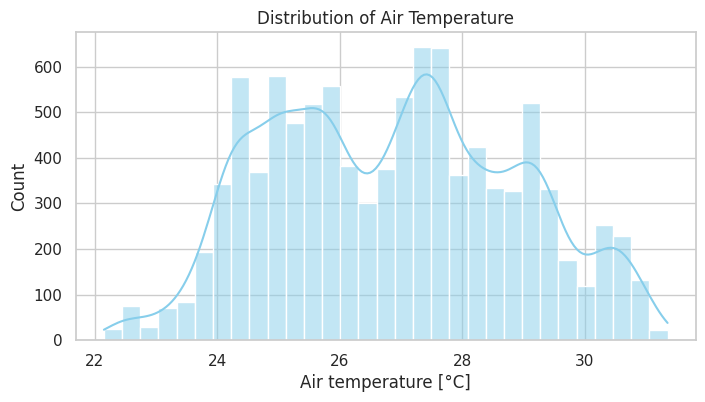

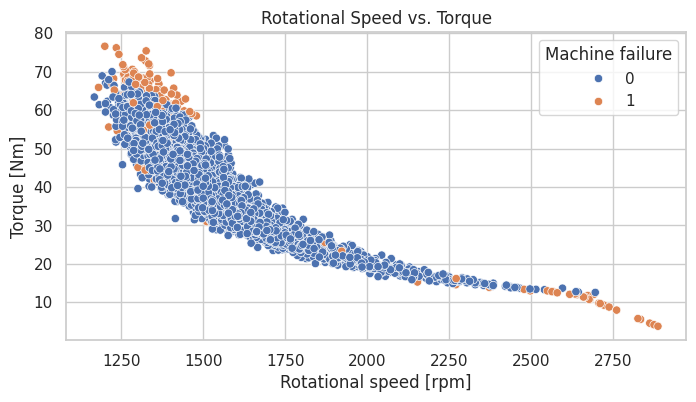

/tmp/ipykernel_5408/32150394.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Type', palette='viridis')


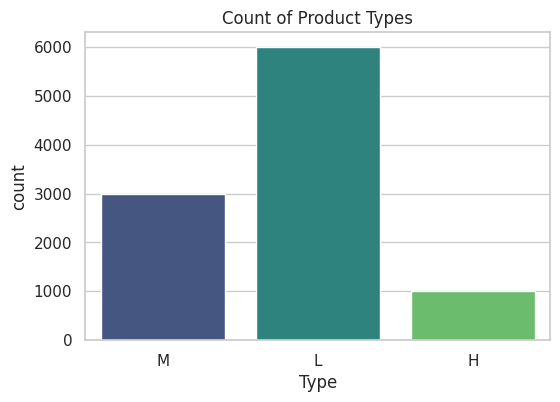

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Distribution Analysis (Example: Air Temperature)
plt.figure(figsize=(8, 4))
sns.histplot(df['Air temperature [°C]'], kde=True, color='skyblue')
plt.title('Distribution of Air Temperature')
plt.show()

# 2. Relationship Analysis (Example: Rotational Speed vs Torque)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure')
plt.title('Rotational Speed vs. Torque')
plt.show()

# 3. Categorical Analysis (Example: Product Type)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Type', palette='viridis')
plt.title('Count of Product Types')
plt.show()

In [ ]:
# Check for missing values in the entire dataframe
missing_values = df.isnull().sum()
print(missing_values)

UDI                         0
Product ID                  0
Type                        0
Rotational speed [rpm]      0
Torque [Nm]                 0
Tool wear [min]             0
Machine failure             0
TWF                         0
HDF                         0
PWF                         0
OSF                         0
RNF                         0
Air temperature [°C]        0
Process temperature [°C]    0
dtype: int64


count    10000.000000
mean        39.986910
std          9.968934
min          3.800000
25%         33.200000
50%         40.100000
75%         46.800000
max         76.600000
Name: Torque [Nm], dtype: float64


<Axes: xlabel='Torque [Nm]'>

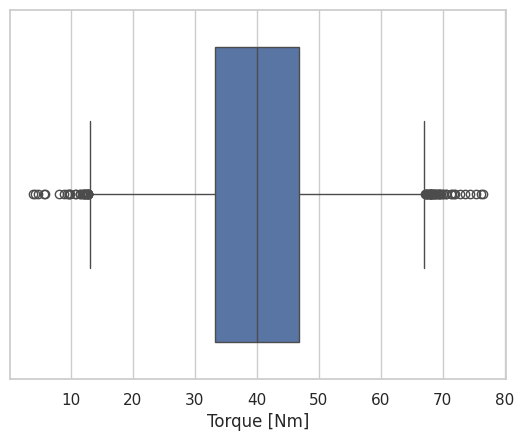

In [ ]:
# Use descriptive statistics to identify potential physical outliers
print(df['Torque [Nm]'].describe())

# Optional: Visualize using a boxplot to spot extreme anomalies
sns.boxplot(x=df['Torque [Nm]'])

In [ ]:
# 1. Feature Creation: Power Calculation
df['Power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

# 2. Feature Encoding: One-Hot Encoding for 'Type'
# This creates new columns like Type_L, Type_M, and Type_H
df = pd.get_dummies(df, columns=['Type'], prefix='Type')

# 3. Verification: Preview the new columns
display(df.head())

,UDI,Product ID,Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Air temperature [°C],Process temperature [°C],Power,Type_H,Type_L,Type_M
0,1,M14860,1551,42.8,0,0,0,0,0,0,0,24.95,35.45,66382.8,False,False,True
1,2,L47181,1408,46.3,3,0,0,0,0,0,0,25.05,35.55,65190.4,False,True,False
2,3,L47182,1498,49.4,5,0,0,0,0,0,0,24.95,35.35,74001.2,False,True,False
3,4,L47183,1433,39.5,7,0,0,0,0,0,0,25.05,35.45,56603.5,False,True,False
4,5,L47184,1408,40.0,9,0,0,0,0,0,0,25.05,35.55,56320.0,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Define Features (X) and Target (y)
# Drop original columns that are not useful or are leakage
X = df.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Product ID','UDI'])
y = df['Machine failure']

# 2. Split Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Baseline Model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

# 4. Evaluate
y_pred = baseline_model.predict(X_test)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Baseline Accuracy: 0.9725
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.62      0.25      0.35        61

    accuracy                           0.97      2000
   macro avg       0.80      0.62      0.67      2000
weighted avg       0.97      0.97      0.97      2000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize a Random Forest model
# We use 'class_weight="balanced"' to tell the model to pay more attention to the rare failure cases
improved_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Train the improved model
improved_model.fit(X_train, y_train)

# 3. Evaluate
y_pred_imp = improved_model.predict(X_test)
print("Improved Accuracy:", accuracy_score(y_test, y_pred_imp))
print(classification_report(y_test, y_pred_imp))

Improved Accuracy: 0.9865
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.95      0.59      0.73        61

    accuracy                           0.99      2000
   macro avg       0.97      0.79      0.86      2000
weighted avg       0.99      0.99      0.98      2000



In [ ]:
def validate_data(df):
    print("--- Starting Automated Data Validation ---")

    # 1. Check for missing values
    missing = df.isnull().sum().sum()
    print(f"Missing values found: {missing}")

    # 2. Check for duplicate rows
    duplicates = df.duplicated().sum()
    print(f"Duplicate rows found: {duplicates}")

    # 3. Check for physical constraints (e.g., Torque cannot be negative)
    negative_torque = (df['Torque [Nm]'] < 0).sum()
    print(f"Invalid (negative) torque entries: {negative_torque}")

    if missing == 0 and duplicates == 0 and negative_torque == 0:
        print("Validation Status: PASSED")
    else:
        print("Validation Status: FAILED - Data requires cleaning")

# Run the validation
validate_data(df)

--- Starting Automated Data Validation ---
Missing values found: 0
Duplicate rows found: 0
Invalid (negative) torque entries: 0
Validation Status: PASSED
